In [1]:
from sympy import is_increasing #判断是否单调递增,是函数
from sympy.abc import x,y
from sympy import Interval,oo #导入配置区间的类和无穷大符号

In [3]:
expr_1 = -x**2
#Iterval用类的.open()表示开区间.Lopen()表示左开右闭.Ropen()表示左闭右开
#increasing函数第二个必须是Interval的区间对象
print(is_increasing(expr_1,Interval(-oo,0)))
print(is_increasing(expr_1,Interval(0,oo)))

True
False


In [5]:
expr_2 = -x**2 + y
#第三个变量表示测试特定变量的单调性
#is_increasing函数如果指定了第三个参数,函数的自变量视为只有第三个参数的符号,其他项都视为常数项
    #如果有多个自变量,但是没有指定参数,会报错
    #只定义了一个自变量,自动按照这个自变量判断
print(is_increasing(expr_2,Interval(-1,2),x))

False


In [6]:
import numpy as np
from sympy import lambdify,diff,exp,latex,simplify
from sympy.abc import x,y
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm

In [7]:
num = 301
x_array = np.linspace(-3,3,num)
y_array = np.linspace(-3,3,num)
xx,yy = np.meshgrid(x_array,y_array)

In [8]:
plt.close('all')

In [9]:
f_xy =  3*(1-x)**2*exp(-(x**2) - (y+1)**2)\
    - 10*(x/5 - x**3 - y**5)*exp(-x**2-y**2)\
    - 1/3*exp(-(x+1)**2 - y**2) 

f_xy_fcn = lambdify([x,y],f_xy)
f_xy_zz = f_xy_fcn(xx,yy)

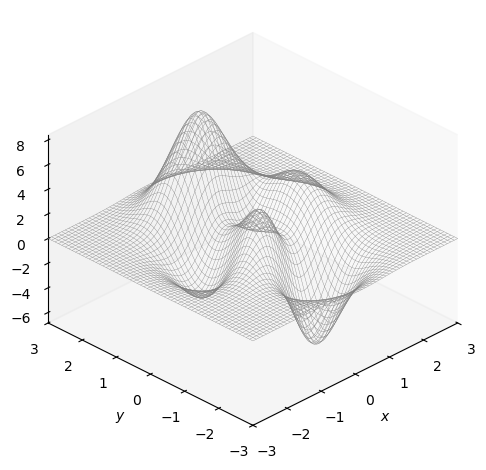

In [17]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})

ax.plot_wireframe(xx,yy,f_xy_zz,
                  color = '0.5',rstride = 5,cstride = 5,
                  linewidth = 0.25)
ax.set_proj_type('ortho')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$f(x,y)$')
ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())
ax.view_init(azim = -135,elev = 30)
plt.tight_layout()
ax.grid(False)

x_2 = -3
f(x1,x2 = -3) = 10*x**3*exp(-x**2 - 9) - 2*x*exp(-x**2 - 9) + 3*(x - 1)**2*exp(-x**2 - 4) - 2430*exp(-x**2 - 9) - 0.333333333333333*exp(-(x + 1)**2 - 9))
x_2 = -2
f(x1,x2 = -2) = 10*x**3*exp(-x**2 - 4) - 2*x*exp(-x**2 - 4) + 3*(x - 1)**2*exp(-x**2 - 1) - 320*exp(-x**2 - 4) - 0.333333333333333*exp(-(x + 1)**2 - 4))
x_2 = -1
f(x1,x2 = -1) = 10*x**3*exp(-x**2 - 1) - 2*x*exp(-x**2 - 1) + 3*(x - 1)**2*exp(-x**2) - 10*exp(-x**2 - 1) - 0.333333333333333*exp(-(x + 1)**2 - 1))
x_2 = 0
f(x1,x2 = 0) = 10*x**3*exp(-x**2) - 2*x*exp(-x**2) + 3*(x - 1)**2*exp(-x**2 - 1) - 0.333333333333333*exp(-(x + 1)**2))
x_2 = 1
f(x1,x2 = 1) = 10*x**3*exp(-x**2 - 1) - 2*x*exp(-x**2 - 1) + 3*(x - 1)**2*exp(-x**2 - 4) + 10*exp(-x**2 - 1) - 0.333333333333333*exp(-(x + 1)**2 - 1))
x_2 = 2
f(x1,x2 = 2) = 10*x**3*exp(-x**2 - 4) - 2*x*exp(-x**2 - 4) + 3*(x - 1)**2*exp(-x**2 - 9) + 320*exp(-x**2 - 4) - 0.333333333333333*exp(-(x + 1)**2 - 4))
x_2 = 3
f(x1,x2 = 3) = 10*x**3*exp(-x**2 - 9) - 2*x*exp(-x**2 - 9) + 3*(

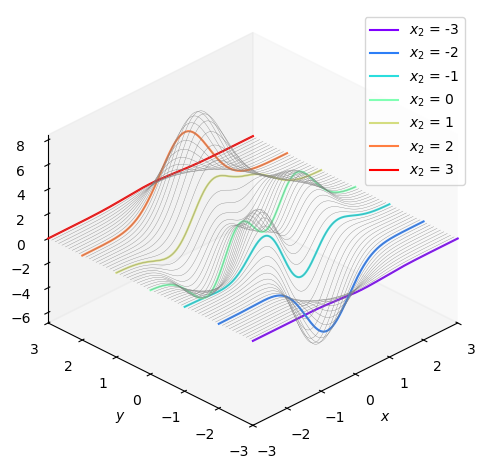

In [42]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})
ax.plot_wireframe(xx,yy,f_xy_zz,
                  color = '0.5',
                  rstride = 5,cstride = 0,
                  linewidth = 0.25)

colors = plt.cm.rainbow(np.linspace(0,1,7))

i = 0

for b in np.arange(-3,4,1):
    f_xy_b = f_xy.subs(y,b)#符号表达式中的方法,将y替换为b

    print('==========')
    #0.0f中的第一个0表示最小宽度(基本无意义),第二个0表示保留0位小数等价于浮点数按照整数显示出来,按照四舍五入保留
    print('x_2 = %0.0f'%b)
    #%后的s表示字符串str,会自动调用str()处理插入数值,但是后面依旧调用了str()是多余的,相当于字符串传递到了字符串函数,不会报错
    print('f(x1,x2 = %0.0f) = %s)' %(b,str(simplify(f_xy_b))))
    print('==========')

    f_xy_b_fcn = lambdify([x],f_xy_b)
    f_xy_b_zz = f_xy_b_fcn(x_array)

    ax.plot(x_array,x_array*0 + b,f_xy_b_zz,
           color = colors[i,:],
           label = '$x_2$ = %0.0f'%b)

    i = i+1

plt.legend()#自动收集带label的绘图对象,显示图例
ax.set_proj_type('ortho')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$f(x,y)$')
ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())
ax.view_init(azim = -135,elev = 30)
plt.tight_layout()
ax.grid(False)

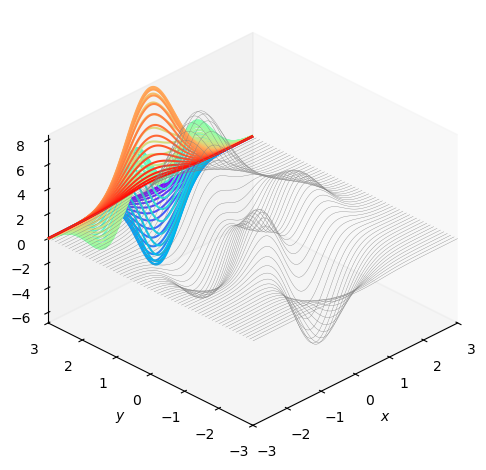

In [31]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})
ax.plot_wireframe(xx,yy,f_xy_zz,
                  color = '0.5',
                  rstride = 5,cstride = 0,
                  linewidth = 0.25)

#沿着y方向垂直投影,投影到offset的平面上
ax.contour(xx,yy,f_xy_zz,
           levels = 60,zdir = 'y',
           offset = yy.max(),cmap = 'rainbow')

ax.set_proj_type('ortho')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$f(x,y)$')
ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())
ax.view_init(azim = -135,elev = 30)
plt.tight_layout()
ax.grid(False)

(-3.0, 3.0)

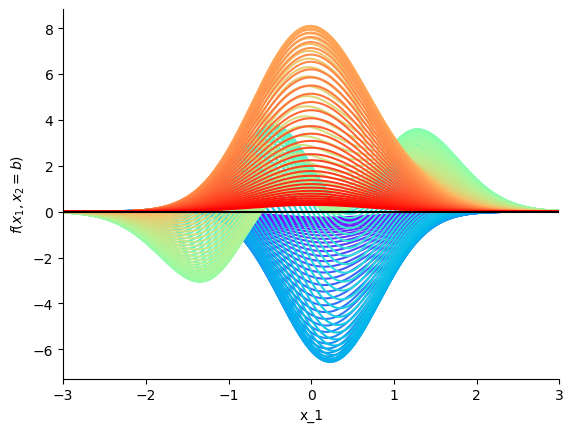

In [41]:
down_step = 2

y_array_downsample = y_array[0::down_step]

fig,ax = plt.subplots()

colors = plt.cm.rainbow(np.linspace(0,1,len(y_array_downsample)))

for i in np.linspace(1,len(y_array_downsample),len(y_array_downsample)):
    plt.plot(x_array,f_xy_zz[(int(i) - 1)*down_step,:],
             color = colors[int(i) - 1])

plt.axhline(y = 0,color = 'k',linestyle = '-')
ax.spines[['right','top']].set_visible(False)
plt.xlabel('x_1')
plt.ylabel('$f(x_1,x_2 = b)$')
ax.set_xlim(xx.min(),xx.max())

x_1 = -3
f(x1 = -3,x2) = (10.0*y**5*exp(2*y + 1) - 264.0*exp(2*y + 1) - 0.333333333333333*exp(2*y + 6) + 48.0)*exp(-y**2 - 2*y - 10))
x_1 = -2
f(x1 = -2,x2) = (10.0*y**5*exp(2*y + 1) - 76.0*exp(2*y + 1) - 0.333333333333333*exp(2*y + 4) + 27.0)*exp(-y**2 - 2*y - 5))
x_1 = -1
f(x1 = -1,x2) = (10.0*y**5*exp(2*y + 1) - 8.0*exp(2*y + 1) - 0.333333333333333*exp(2*y + 2) + 12.0)*exp(-y**2 - 2*y - 2))
x_1 = 0
f(x1 = 0,x2) = (10.0*y**5*exp(2*y + 1) - 0.333333333333333*exp(2*y) + 3.0)*exp(-y**2 - 2*y - 1))
x_1 = 1
f(x1 = 1,x2) = (10.0*y**5*exp(3) - 0.333333333333333 + 8.0*exp(3))*exp(-y**2 - 4))
x_1 = 2
f(x1 = 2,x2) = (10.0*y**5*exp(2*y + 5) - 0.333333333333333*exp(2*y) + 76.0*exp(2*y + 5) + 3.0*exp(4))*exp(-y**2 - 2*y - 9))
x_1 = 3
f(x1 = 3,x2) = (10.0*y**5*exp(2*y + 7) - 0.333333333333333*exp(2*y) + 264.0*exp(2*y + 7) + 12.0*exp(6))*exp(-y**2 - 2*y - 16))


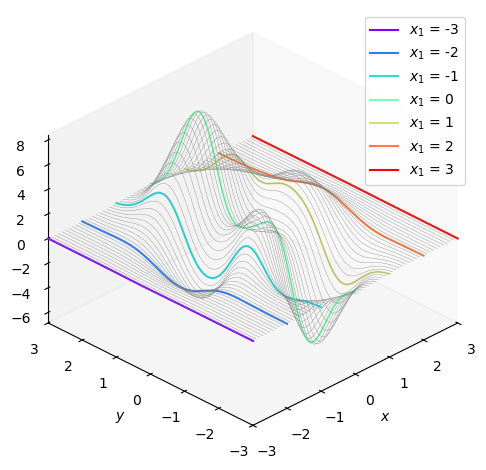

In [45]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})
ax.plot_wireframe(xx,yy,f_xy_zz,
                  color = '0.5',
                  rstride = 0,cstride = 5,
                  linewidth = 0.25)

colors = plt.cm.rainbow(np.linspace(0,1,7))

i = 0

for c in np.arange(-3,4,1):
    f_xy_c = f_xy.subs(x,c)#符号表达式中的方法,将y替换为b

    print('==========')
    #0.0f中的第一个0表示最小宽度(基本无意义),第二个0表示保留0位小数等价于浮点数按照整数显示出来,按照四舍五入保留
    print('x_1 = %0.0f'%c)
    #%后的s表示字符串str,会自动调用str()处理插入数值,但是后面依旧调用了str()是多余的,相当于字符串传递到了字符串函数,不会报错
    print('f(x1 = %0.0f,x2) = %s)' %(c,str(simplify(f_xy_c))))
    print('==========')

    f_xy_c_fcn = lambdify([y],f_xy_c)
    f_xy_c_zz = f_xy_c_fcn(y_array)

    ax.plot(y_array*0+c,y_array,f_xy_c_zz,
           color = colors[i,:],
           label = '$x_1$ = %0.0f'%c)

    i = i+1

plt.legend()#自动收集带label的绘图对象,显示图例
ax.set_proj_type('ortho')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$f(x,y)$')
ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())
ax.view_init(azim = -135,elev = 30)
plt.tight_layout()
ax.grid(False)

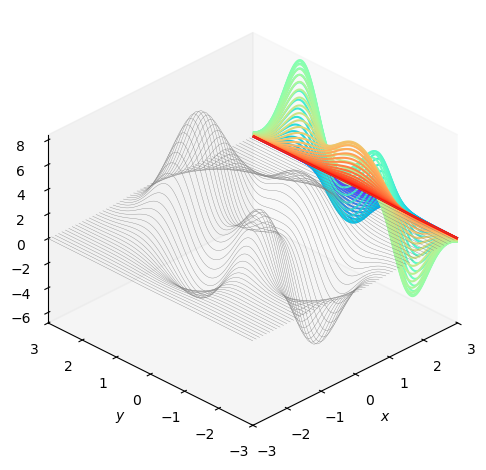

In [47]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})
ax.plot_wireframe(xx,yy,f_xy_zz,
                  color = '0.5',
                  rstride = 0,cstride = 5,
                  linewidth = 0.25)

#沿着y方向垂直投影,投影到offset的平面上
ax.contour(xx,yy,f_xy_zz,
           levels = 60,zdir = 'x',
           offset = xx.max(),cmap = 'rainbow')

ax.set_proj_type('ortho')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$f(x,y)$')
ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())
ax.view_init(azim = -135,elev = 30)
plt.tight_layout()
ax.grid(False)

(-3.0, 3.0)

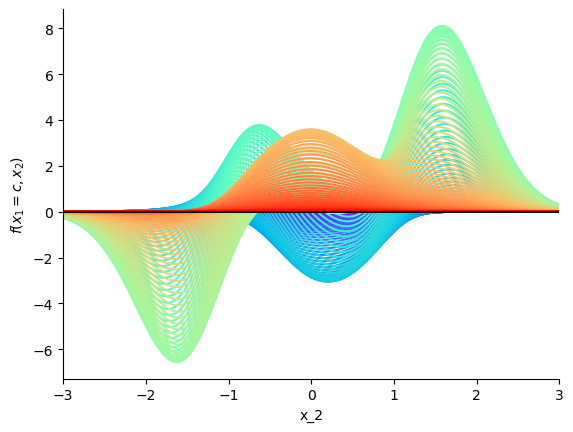

In [56]:
down_step = 2

x_array_downsample = x_array[0::down_step]

fig,ax = plt.subplots()

colors = plt.cm.rainbow(np.linspace(0,1,len(x_array_downsample)))

for i in np.linspace(1,len(x_array_downsample),len(x_array_downsample)):
    plt.plot(y_array,f_xy_zz[:,(int(i) - 1)*down_step],
             color = colors[int(i) - 1])

plt.axhline(y = 0,color = 'k',linestyle = '-')
ax.spines[['right','top']].set_visible(False)
plt.xlabel('x_2')
plt.ylabel('$f(x_1 = c,x_2)$')
ax.set_xlim(xx.min(),xx.max())

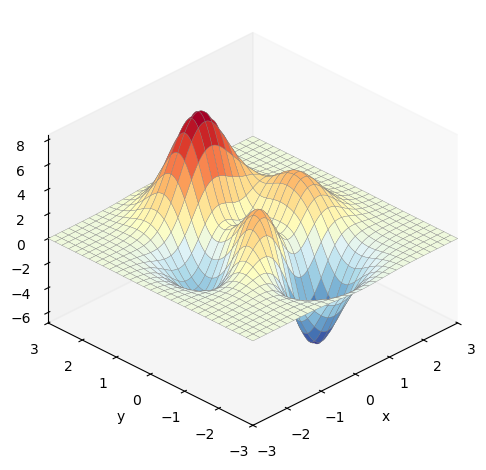

In [59]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})

ax.plot_surface(xx,yy,f_xy_zz,
                cmap = 'RdYlBu_r',
                rstride = 10,cstride = 10,
                linewidth = 0.25,
                edgecolors = '0.5')

ax.set_proj_type('ortho')

plt.xlabel('x')
plt.ylabel('y')
ax.set_zlabel('$f(x,y)$')
ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())
ax.view_init(azim = -135,elev = 30)
plt.tight_layout()
ax.grid(False)

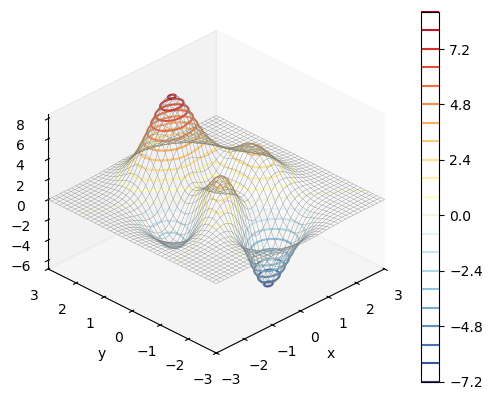

In [64]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})

ax.plot_wireframe(xx,yy,f_xy_zz,
                  color = '0.5',
                  linewidth = 0.25)

colorbar = ax.contour(xx,yy,f_xy_zz,20,cmap = 'RdYlBu_r')
fig.colorbar(colorbar,ax = ax)

ax.set_proj_type('ortho')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('$f(x,y)$')
ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())
ax.view_init(azim = -135,elev = 30)
ax.grid(False)

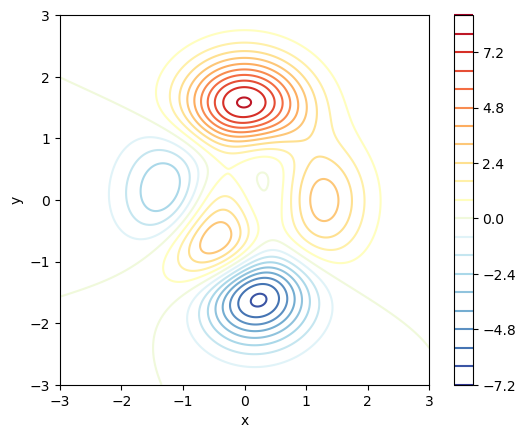

In [67]:
fig,ax = plt.subplots()

colorbar = ax.contour(xx,yy,f_xy_zz,20,cmap = 'RdYlBu_r')
fig.colorbar(colorbar,ax = ax)

ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.gca().set_aspect('equal',adjustable = 'box')

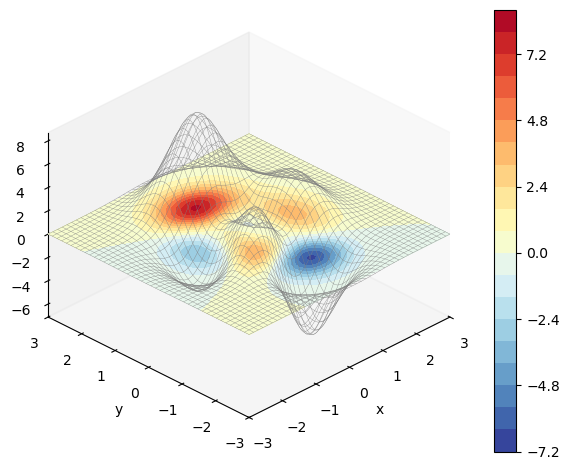

In [70]:
fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})

ax.plot_wireframe(xx,yy,f_xy_zz,
                  color = '0.5',
                  linewidth = 0.25)

colorbar = ax.contourf(xx,yy,f_xy_zz,20,cmap = 'RdYlBu_r',zdir = 'z',offset = 0)
fig.colorbar(colorbar,ax = ax)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('$f(x,y)$')
ax.set_proj_type('ortho')

ax.view_init(azim = -135,elev = 30)

ax.grid(False)

ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())

plt.tight_layout()

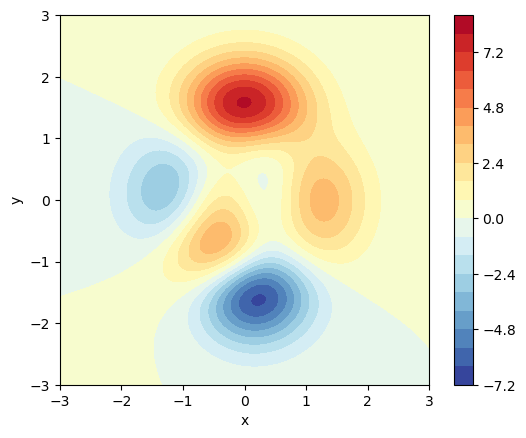

In [71]:
fig,ax = plt.subplots()

colorbar = ax.contourf(xx,yy,f_xy_zz,20,cmap = 'RdYlBu_r')
fig.colorbar(colorbar,ax = ax)

ax.set_xlim(xx.min(),xx.max())
ax.set_ylim(yy.min(),yy.max())

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.gca().set_aspect('equal',adjustable = 'box')